# Lab 06: Gene Expression

---
author: Isabella Iniguez
date: October 30, 2024
embed-resources: true
---

## Introduction

In this report, we develop a classification model that predicts a cancer type given gene expression data. 
By building this model, we aim to work towards a proof of concept, exploring the possibility of developing a "universal” cancer detection and classification model.

## Methods

In [ ]:
# imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# machine learning
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

### Data

In [3]:
# load data
cancer_train = pd.read_parquet(
    "https://cs307.org/lab-06/data/cancer-train.parquet",
)
cancer_test = pd.read_parquet(
    "https://cs307.org/lab-06/data/cancer-test.parquet",
)
cancer_train

,cancer,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,...,gene_1990,gene_1991,gene_1992,gene_1993,gene_1994,gene_1995,gene_1996,gene_1997,gene_1998,gene_1999
0,BRCA,0.0,3.149861,1.913454,5.562355,9.638586,0.0,4.302421,0.511670,0.000000,...,7.300691,8.383307,1.187198,0.000000,7.350471,0.0,4.634587,7.082415,9.727447,1.187198
1,LUAD,0.0,6.237034,5.043235,6.297397,10.391415,0.0,7.669941,0.913033,0.000000,...,6.322446,7.815595,13.809095,0.913033,7.651052,0.0,7.476074,4.733739,8.510863,0.000000
2,BRCA,0.0,3.856896,2.394981,6.758277,9.585513,0.0,7.409009,1.242023,0.000000,...,6.845515,9.194823,5.667696,0.000000,7.748253,0.0,5.567421,5.203158,7.364879,0.000000
3,PRAD,0.0,4.279924,3.606963,5.706613,9.716581,0.0,8.244226,0.402613,0.000000,...,6.598611,8.199118,5.024218,0.000000,7.607907,0.0,5.705281,6.278007,9.725383,0.000000
4,BRCA,0.0,3.359788,4.199986,6.144766,9.141834,0.0,9.014135,1.061776,0.626486,...,7.062651,9.670708,4.243707,0.000000,8.156811,0.0,7.363487,5.384844,8.703443,1.894876
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,KIRC,0.0,3.069737,3.623200,6.744955,9.591219,0.0,7.254254,0.000000,0.000000,...,7.333665,8.365334,5.481444,0.000000,7.307674,0.0,5.723447,5.401791,9.067881,0.000000
124,BRCA,0.0,3.534497,3.064866,6.638882,10.010206,0.0,7.899387,0.000000,0.000000,...,7.080615,9.968912,10.501041,0.000000,8.866052,0.0,5.276806,4.941073,8.548240,0.000000
125,BRCA,0.0,4.087463,3.786596,6.385845,9.544964,0.0,8.062856,0.000000,0.000000,...,5.842979,9.931033,10.234817,0.000000,8.384568,0.0,7.033423,5.749534,8.132371,0.000000
126,LUAD,0.0,3.272889,4.529234,7.134909,9.504362,0.0,5.668893,0.000000,0.000000,...,7.300966,8.040350,11.972872,0.000000,7.592607,0.0,5.026256,6.137704,8.780947,1.167936


### Data Dictionary

Each observation in the `train` and `test` data contains clinical and gene expression information from a tissue sample of a cancer patient.

The variables considered are:

#### Response

`cancer`

-   `[object]` the clinically determined cancer type, one of:
    -    BRCA: Breast Invasive Carcinoma
    -   PRAD: Prostate Adenocarcinoma
    -   KIRC: Kidney Renal Clear Cell Carcinoma
    -   LUAD: Lung Adenocarcinoma
    -   COAD: Colon Adenocarcinoma

#### Features

`gene_`

-   `[float64]` gene expression quantification as measured by an Illumina HiSeq platform

In [4]:
# summary statistics
print("Number of Samples: ", len(cancer_train))
print("Number of Features: ", len(cancer_train.columns) - 1)

Number of Samples:  128
Number of Features:  2000


In [5]:
# Count of Observations by Cancer
cancer_train[['cancer','gene_0']].groupby("cancer").agg('count').rename(columns={'gene_0':'count'})

,count
cancer,
BRCA,47
COAD,10
KIRC,19
LUAD,28
PRAD,24


<Figure size 1000x800 with 0 Axes>

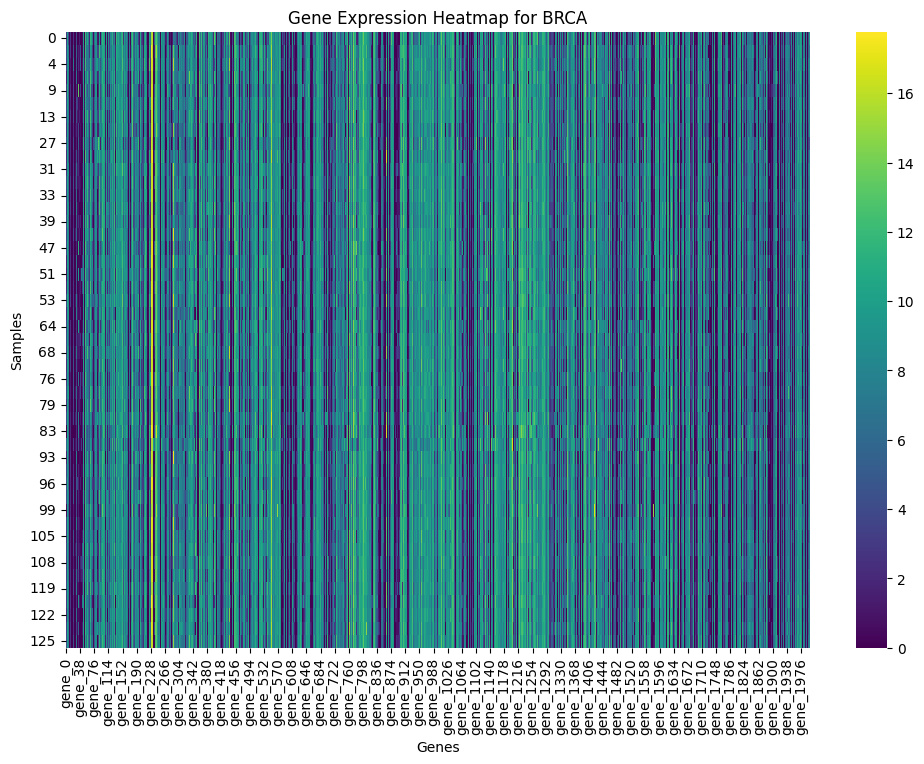

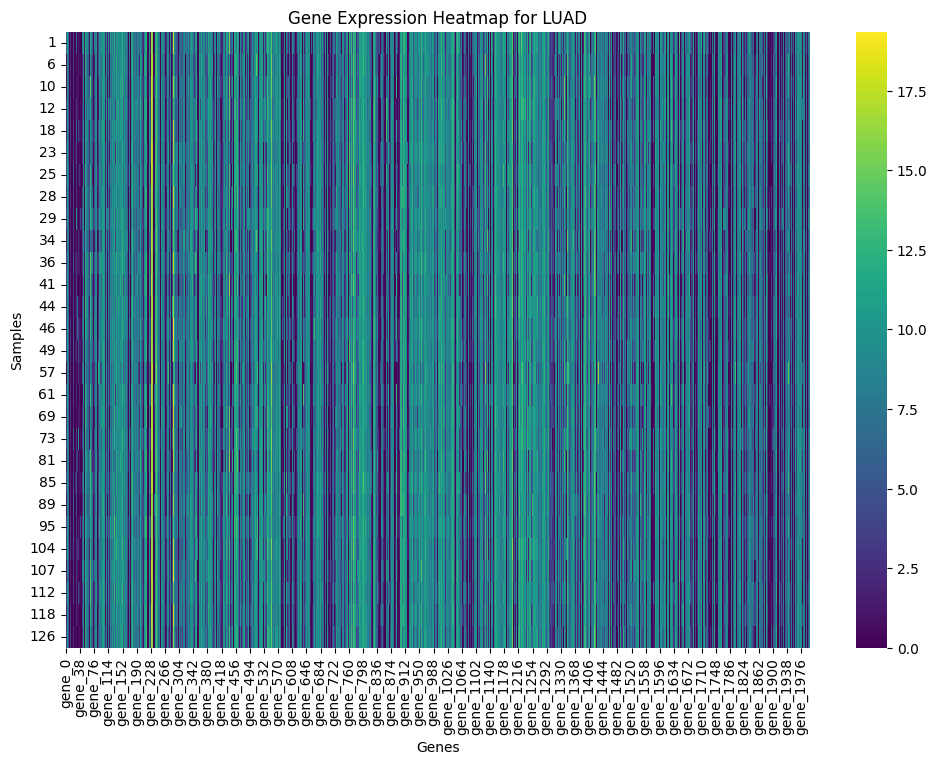

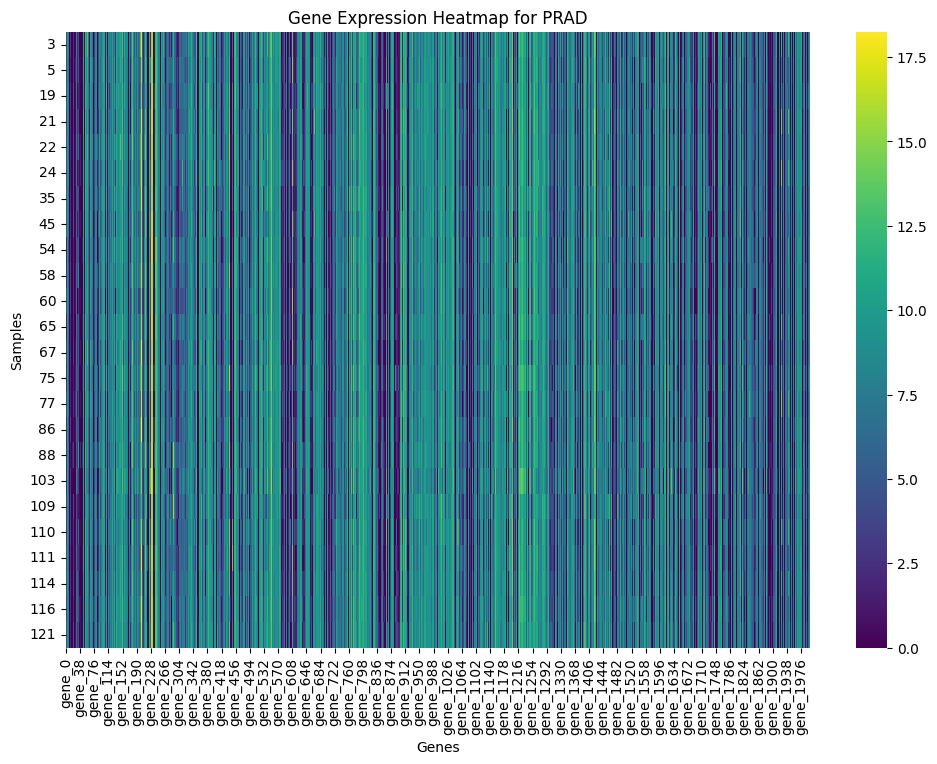

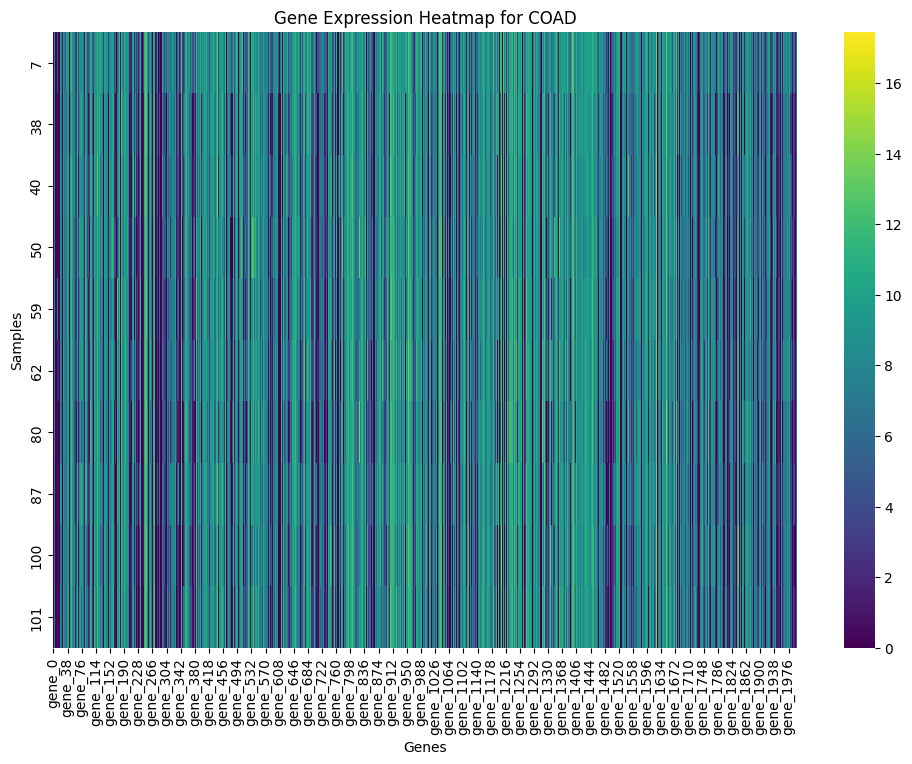

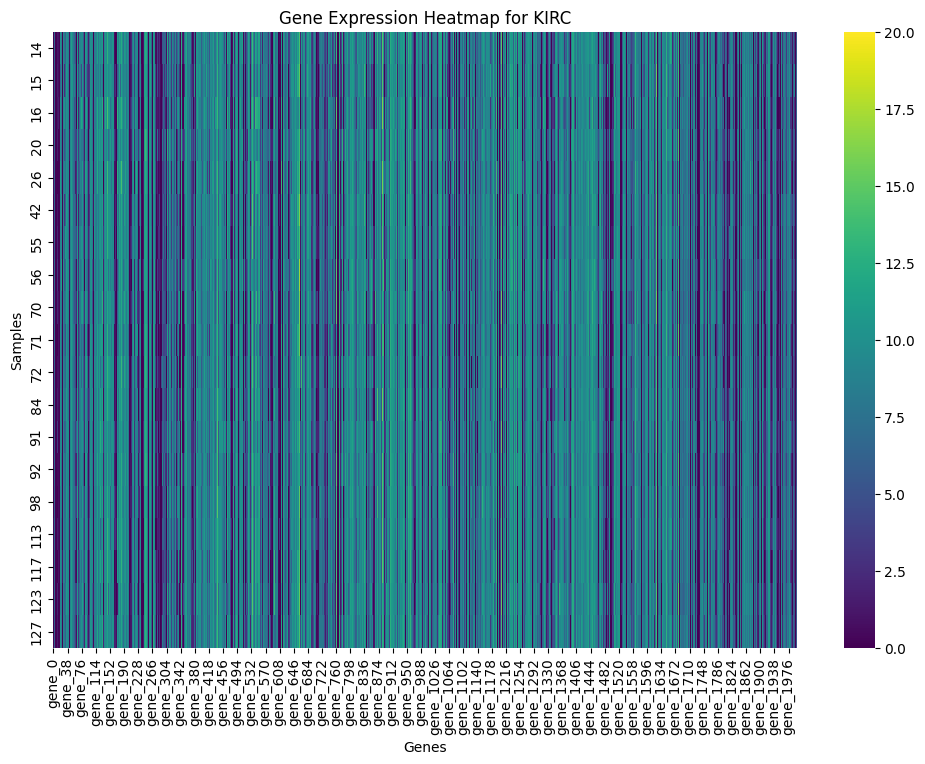

In [34]:
# visualizations
cancer_types = cancer_train['cancer'].unique()
plt.figure(figsize=(10, 8))

for cancer_type in cancer_types:
    cancer_data = cancer_train[cancer_train['cancer'] == cancer_type]
    gene_data = cancer_data.loc[:, 'gene_0':'gene_1999']

    plt.figure(figsize=(12, 8))
    sns.heatmap(gene_data, cmap="viridis", cbar=True)
    plt.title(f"Gene Expression Heatmap for {cancer_type}")
    plt.xlabel("Genes")
    plt.ylabel("Samples")
    plt.show()


When analyzing the data, the first thing one may notice is the fact that we are working with very few samples compared to our many, many features. Having very few samples but many features can lead to challenges in fitting a model. For example, such few data points may make it difficult for the model to distinguish between them. This is especially so if there is an uneven distribution of each cancer, which we do see in our case (e.g. BRCA has 47 observations while COAD only has 10). 

Visualizing this data is particularly difficult; however, the above visualization helps give the general idea of the gene expression patterns among each cancer type. The noticeable shifts in hues across each cancer type indicates that our classifier model may have a good chance at picking up on these trends.

### Models

In [35]:
# process data for ML
# create X and y for train
X_train = cancer_train.drop(columns=["cancer"])
y_train = cancer_train["cancer"]

# create X and y for test
X_test = cancer_test.drop(columns=["cancer"])
y_test = cancer_test["cancer"]

In [36]:
# train models
# define preprocessing for numeric features
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
    ]
)

# combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, X_train.columns.tolist()),
    ]
)

# create pipeline, preprocess then classify
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LogisticRegression(penalty=None)),
    ]
)

pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['gene_0', 'gene_1', 'gene_2',
                                                   'gene_3', 'gene_4', 'gene_5',
                                                   'gene_6', 'gene_7', 'gene_8',
                                                   'gene_9', 'gene_10',
                                                   'gene_11', 'gene_12',
                                                   'gene_13', 'gene_14',
                                                   'gene_15', 'gene_16',
                                                   'gene_17', 'gene_18',
                                                   'gene_19', 'gene_20',
                                                   'gene_21', 'gene_22',
                                                   'gene_23', 'gene_24',
                                                   'gene_25', 'gene_26',
                                                   'gene_27', 'gene_28',
                                                   'gene_29', ...])])),
                ('regressor', LogisticRegression(penalty=None))])

In [37]:
# define parameter grid
param_grid = {
    "preprocessor__num__scaler": [None, StandardScaler()],
    "regressor__solver": ['liblinear'],
    "regressor__penalty": ["l2", "l1"],
    "regressor__random_state": [307],
}

In [38]:
# setup grid search with cross-validation
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring="accuracy")

In [39]:
# run grid search with cross-validation
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['gene_0',
                                                                          'gene_1',
                                                                          'gene_2',
                                                                          'gene_3',
                                                                          'gene_4',
                                                                          'gene_5',
                                                                          'gene_6',
                                                                          'gene_7',
                                                                          'gene_8',
                                                                          'gene_9',
                                                                          'gene_10',
                                                                          'gene_11',
                                                                          'gene_12',
                                                                          'gene_13',
                                                                          'gene_14',
                                                                          'gene_15',
                                                                          'gene_16',
                                                                          'gene_17',
                                                                          'gene_...
                                                                          'gene_19',
                                                                          'gene_20',
                                                                          'gene_21',
                                                                          'gene_22',
                                                                          'gene_23',
                                                                          'gene_24',
                                                                          'gene_25',
                                                                          'gene_26',
                                                                          'gene_27',
                                                                          'gene_28',
                                                                          'gene_29', ...])])),
                                       ('regressor',
                                        LogisticRegression(penalty=None))]),
             param_grid={'preprocessor__num__scaler': [None, StandardScaler()],
                         'regressor__penalty': ['l2', 'l1'],
                         'regressor__random_state': [307],
                         'regressor__solver': ['liblinear']},
             scoring='accuracy')

In [40]:
# print best parameters found and best (cross-validated) score
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_}")

Best parameters: {'preprocessor__num__scaler': None, 'regressor__penalty': 'l2', 'regressor__random_state': 307, 'regressor__solver': 'liblinear'}
Best cross-validation accuracy: 1.0


Here we used a tuning pipeline to try and find the best cross-validated penalized logistic regression model.

## Results

In [41]:
# report model metrics
# final evaluation on test set
y_pred = grid_search.predict(X_test)
print(f"Test set accuracy: {accuracy_score(y_test, y_pred)}")

Test set accuracy: 1.0


The selected model achieves a test accuracy of 1.0.

## Discussion

Given that the model achieved a perfect final test accuracy of 1.0, this model appears to be a great predictor of cancer type. However, we have to acknowledge the model's limitations when it comes to it's converage.

While this model shows ideal performance, it is limited to predicting from a selection of five cancers. In realtity there are many more cancer types, so to be able to further explore the possibility of a universal cancer detector/classifier we would, for one, need to expand the dataset. Gathering a broader range of cancer types and more samples would allow our model to have a greater range of cancers it can predict (making it more "universal") while also ensuring the model learns generalizable patterns (addressing the issues mentioned in the data discussion section). 


### Conclusion

Given the ideal performance, I would conclude that this model serves as a great proof of concept for the “universal” cancer detection/classification model.

In [42]:
from joblib import dump
dump(grid_search, "gene-expression.joblib")

['gene-expression.joblib']